# Day 5-2: MobileNetV2 Transfer Learning

**강의 시간**: 2시간  
**학습 목표**:
- MobileNetV2 아키텍처 이해
- Transfer Learning (2-phase)
- Data Augmentation 적용
- 경량 모델로 90%+ 정확도 달성

**사전 요구사항**: Day 5-1 완료  
**목표 성능**: Accuracy 90%+, Size < 20MB, Latency < 30ms

## 🔧 0. 환경 설정 (Day 5-1과 동일)

In [1]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow opencv-python scikit-learn

print("✅ 라이브러리 설치 완료!")

✅ 라이브러리 설치 완료!


In [2]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import mlflow
import dagshub

np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU: {len(tf.config.list_physical_devices('GPU'))} devices")

✅ TensorFlow 2.19.0
✅ GPU: 1 devices


In [3]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# MLflow 설정
import mlflow
import dagshub

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day5-gesture-recognition')

print("✅ MLflow 설정 완료!")

Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📂 1. 데이터 로딩 (Day 5-1과 동일)

**참고**: Day 5-1에서 다운로드한 데이터를 재사용합니다.  
데이터가 없다면 Day 5-1 노트북을 먼저 실행하세요.

### HaGRID Subset 다운로드

**옵션 1**: Kaggle에서 다운로드  
**옵션 2**: Google Drive에서 다운로드 (준비된 subset)

이 노트북에서는 Google Drive subset을 사용합니다.

In [ ]:
import os
from google.colab import userdata

# 1. [가장 중요] kaggle 라이브러리를 임포트하기 "전"에 환경 변수를 먼저 설정합니다.
# 보안 비밀에 KAGGLE_USERNAME(내 아이디)과 KAGGLE_API_TOKEN(키 문자열)이 있어야 합니다.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')      # Python API용 표준 이름
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN') # 최신 토큰 방식 호환용

# 2. 환경 변수가 설정된 후 비로소 라이브러리를 불러옵니다.
try:
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate() # 이제 환경 변수를 인식하고 에러 없이 통과합니다.

    # 3. 데이터셋 다운로드 실행
    dataset_id = 'innominate817/hagrid-classification-512p-no-gesture-150k'
    print(f"📥 {dataset_id} 다운로드 시작...")

    api.dataset_download_files(
        dataset_id,
        path='./data',
        unzip=True,
        quiet=False
    )

    print("\n✅ 다운로드 및 압축 해제 완료!")

except Exception as e:
    print(f"\n❌ 오류 발생: {e}")

📥 innominate817/hagrid-classification-512p-no-gesture-150k 다운로드 시작...
Dataset URL: https://www.kaggle.com/datasets/innominate817/hagrid-classification-512p-no-gesture-150k


100%|██████████| 3.55G/3.55G [00:01<00:00, 2.47GB/s]




✅ 다운로드 및 압축 해제 완료!


In [5]:
# 데이터 경로 확인
data_dir = Path('./data/hagrid-classification-512p-no-gesture-150k')

if not data_dir.exists():
    print("❌ 데이터 폴더가 없습니다!")
    print("   Day 5-1 노트북을 먼저 실행하여 데이터를 다운로드하세요.")
else:
    print("✅ 데이터 폴더 확인")

    gesture_folders = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    gesture_names = [f.name for f in gesture_folders]

    print(f"   클래스 수: {len(gesture_names)}")

✅ 데이터 폴더 확인
   클래스 수: 19


In [6]:
# 파일 경로 수집
all_paths = []
all_labels = []

gesture_to_idx = {name: idx for idx, name in enumerate(gesture_names)}

print("📋 파일 경로 수집 중...")

for gesture_name in gesture_names:
    gesture_folder = data_dir / gesture_name
    image_paths = list(gesture_folder.glob('*.jpeg'))

    for img_path in image_paths:
        all_paths.append(str(img_path))
        all_labels.append(gesture_to_idx[gesture_name])

print(f"✅ 총 {len(all_paths):,}개 이미지")

# Train/Val/Test Split (70/15/15)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(f"\nTrain: {len(train_paths):,}개 (70%)")
print(f"Val  : {len(val_paths):,}개 (15%)")
print(f"Test : {len(test_paths):,}개 (15%)")

📋 파일 경로 수집 중...
✅ 총 153,735개 이미지

Train: 107,614개 (70%)
Val  : 23,060개 (15%)
Test : 23,061개 (15%)


## 🎨 2. Data Augmentation

In [7]:
# Data Augmentation 레이어
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),        # 좌우 반전 (제스처에 적합)
    layers.RandomRotation(0.1),             # ±10도 회전
    layers.RandomZoom(0.1),                 # ±10% 확대/축소
    layers.RandomTranslation(0.1, 0.1),     # ±10% 이동
], name='data_augmentation')

print("✅ Data Augmentation 레이어 생성!")
print("   - RandomFlip (horizontal)")
print("   - RandomRotation (±10°)")
print("   - RandomZoom (±10%)")
print("   - RandomTranslation (±10%)")

✅ Data Augmentation 레이어 생성!
   - RandomFlip (horizontal)
   - RandomRotation (±10°)
   - RandomZoom (±10%)
   - RandomTranslation (±10%)


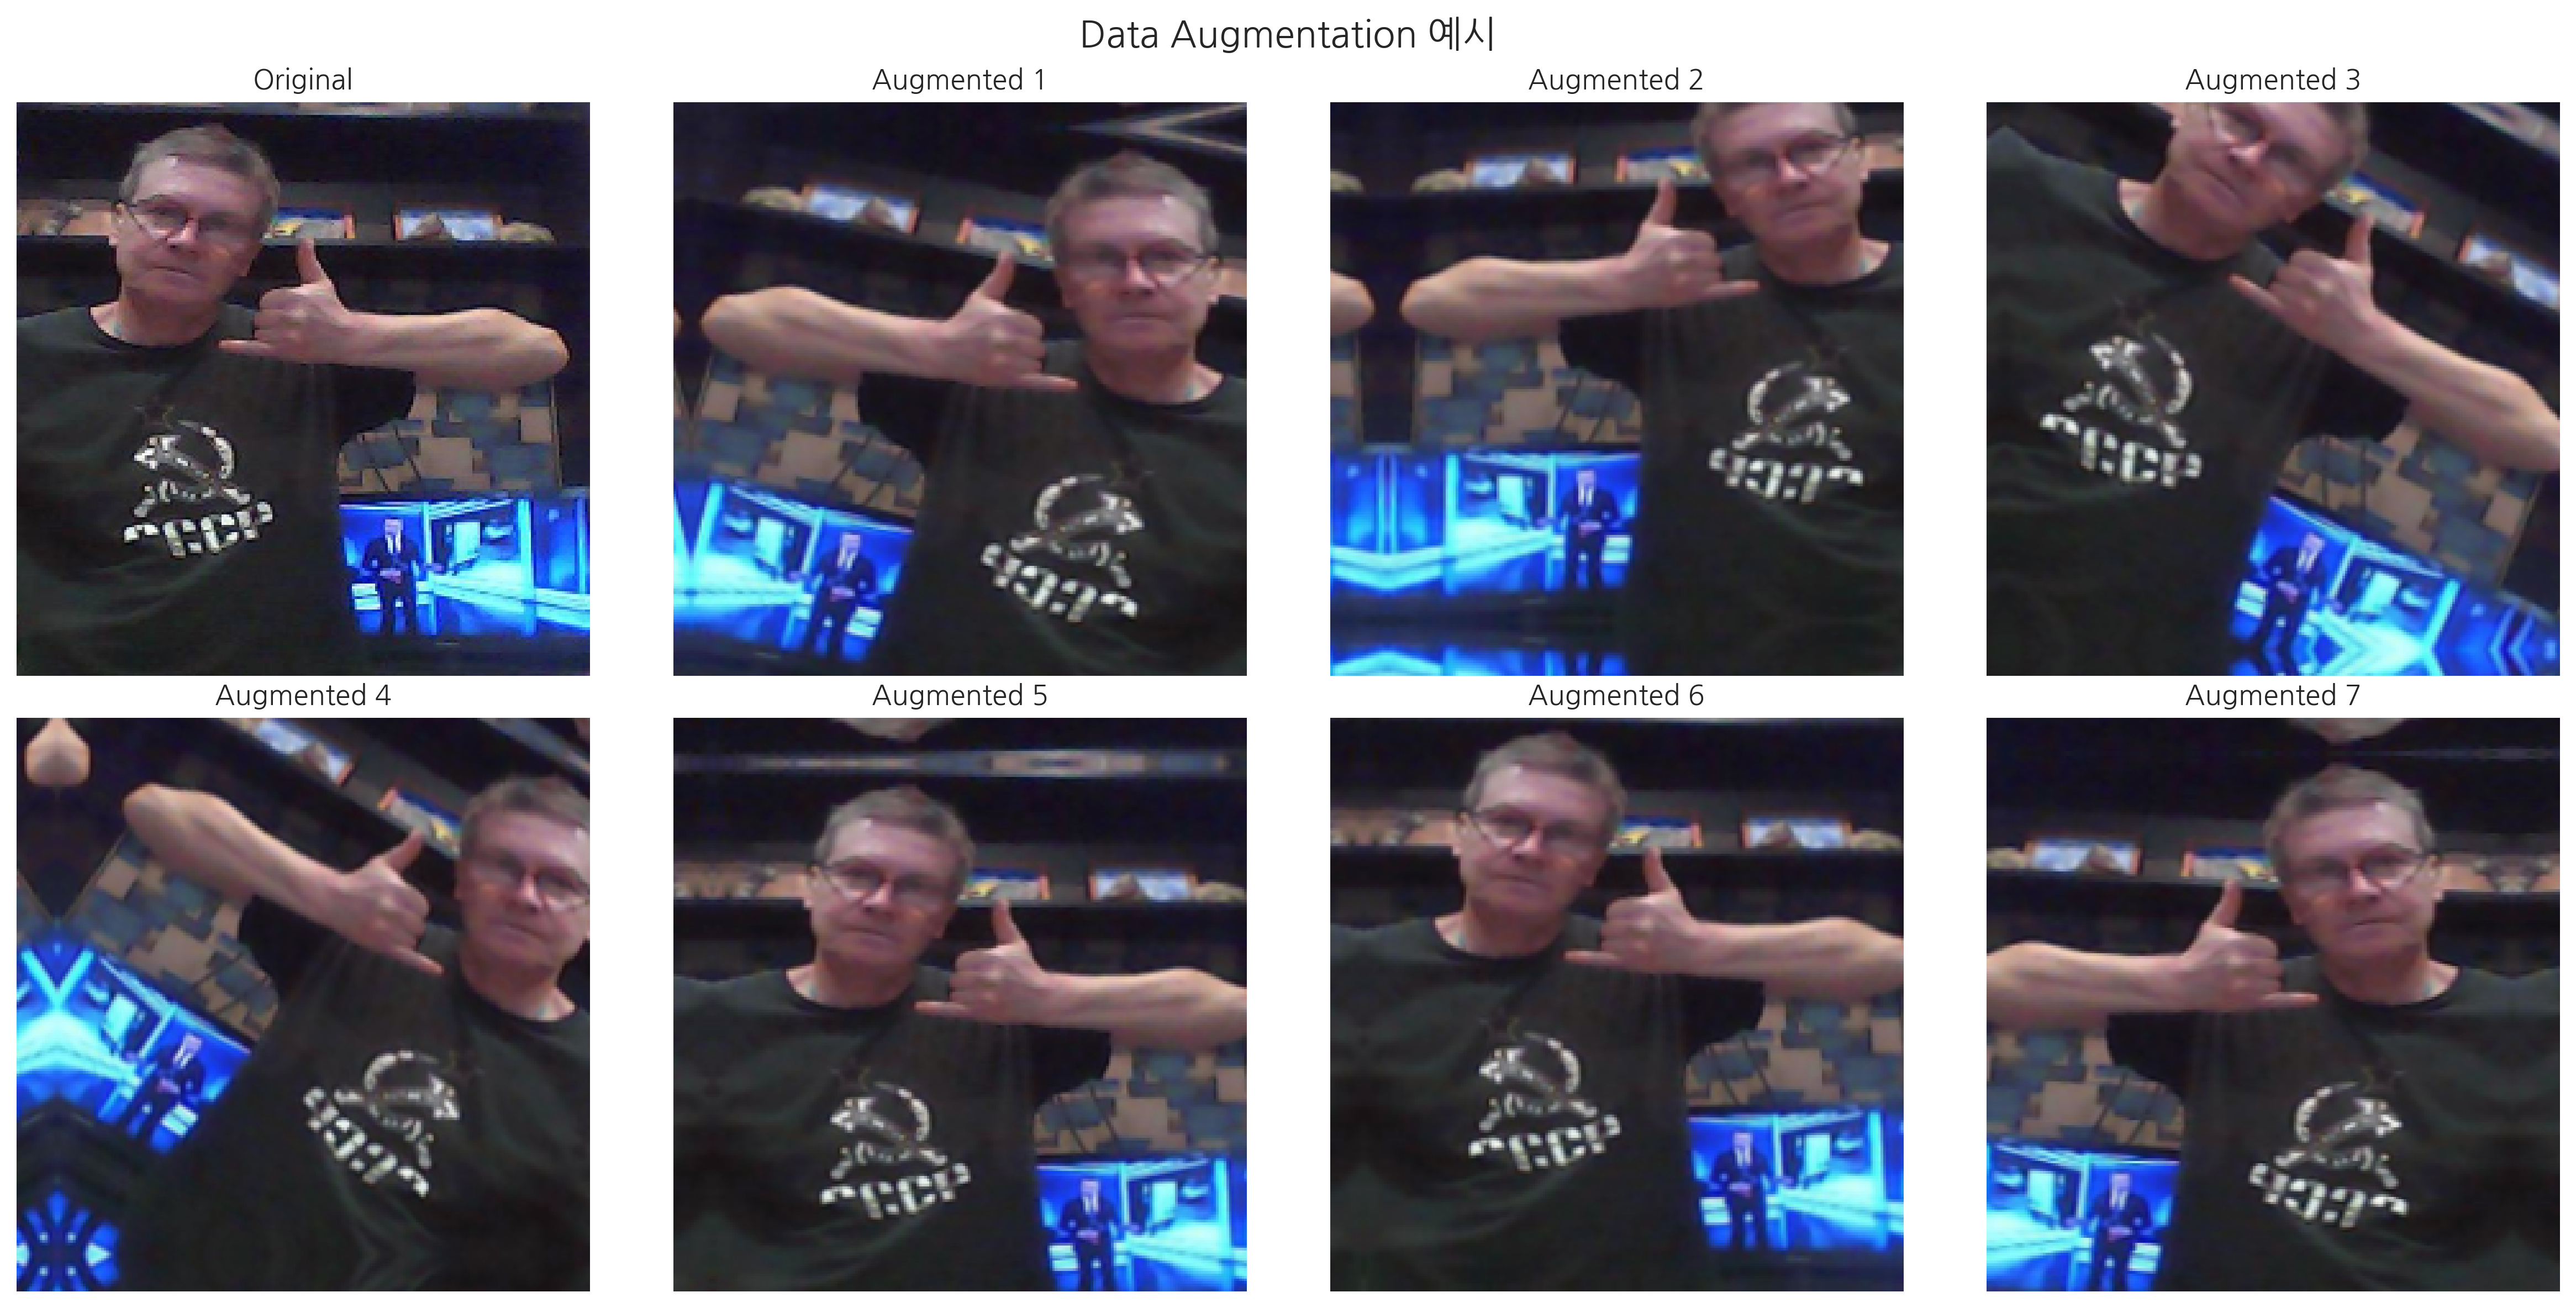

In [8]:
# Augmentation 시각화
# 샘플 이미지 로드
sample_img_path = all_paths[0]
sample_img = cv2.imread(sample_img_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (224, 224))
sample_img = sample_img / 255.0

# Augmentation 적용
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(sample_img)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample_img[np.newaxis, ...], training=True)[0]
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation 예시', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data_augmentation_examples.png', dpi=100, bbox_inches='tight')
plt.show()

## 📊 3. tf.data.Dataset 생성 (MobileNet용)

In [9]:
# Preprocessing 함수 (MobileNet용)
def load_and_preprocess_mobilenet(path, label):
    """MobileNetV2용 전처리"""

    # 이미지 로드
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # 리사이즈
    img = tf.image.resize(img, (224, 224))

    # MobileNetV2 preprocessing (ImageNet 기준)
    img = preprocess_input(img)

    return img, label

print("✅ MobileNetV2 Preprocessing 함수 정의!")
print("   - 512×512 → 224×224 리사이즈")
print("   - ImageNet preprocess_input 적용")

✅ MobileNetV2 Preprocessing 함수 정의!
   - 512×512 → 224×224 리사이즈
   - ImageNet preprocess_input 적용


In [11]:
# tf.data.Dataset 생성
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Train Dataset (with augmentation)
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(load_and_preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.shuffle(1000)

# [중요] 배치를 먼저 생성 → (32, 224, 224, 3)
train_dataset = train_dataset.batch(BATCH_SIZE)

# Augmentation 적용 (배치 단위)
def augment_batch(images, labels):
    """배치 단위로 augmentation 적용"""
    images = data_augmentation(images, training=True)
    return images, labels

train_dataset = train_dataset.map(augment_batch, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

# Val/Test Dataset (no augmentation)
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_dataset = val_dataset.map(load_and_preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_dataset = test_dataset.map(load_and_preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Dataset 생성 완료!")
print(f"   Train batches: {len(train_dataset)} (with augmentation)")
print(f"   Val batches: {len(val_dataset)}")
print(f"   Test batches: {len(test_dataset)}")
print("\n💡 Augmentation은 배치 단위로 적용됩니다.")

✅ Dataset 생성 완료!
   Train batches: 3363 (with augmentation)
   Val batches: 721
   Test batches: 721

💡 Augmentation은 배치 단위로 적용됩니다.


## 🏗️ 4. MobileNetV2 모델 구축

In [12]:
# MobileNetV2 Base Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Phase 1: Freeze base model
base_model.trainable = False

print("✅ MobileNetV2 Base Model 로드 완료!")
print(f"   Pretrained: ImageNet")
print(f"   Trainable: {base_model.trainable}")
print(f"   Parameters: {base_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 Base Model 로드 완료!
   Pretrained: ImageNet
   Trainable: False
   Parameters: 2,257,984


In [13]:
# Custom Classifier 추가
inputs = keras.Input(shape=(224, 224, 3))

# Base model
x = base_model(inputs, training=False)

# Classifier head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(gesture_names), activation='softmax')(x)

model = Model(inputs, outputs, name='MobileNetV2_Gesture')

print("\n✅ 전체 모델 구축 완료!")
print(f"   Total Parameters: {model.count_params():,}")
print(f"   Trainable Parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


✅ 전체 모델 구축 완료!
   Total Parameters: 2,424,403
   Trainable Parameters: 166,419


In [ ]:
# 모델 구조 확인
model.summary()

## 🏃 5. Phase 1: Feature Extraction (Base Frozen)

In [14]:
# Phase 1 컴파일
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Phase 1 컴파일 완료!")
print("   Base Model: Frozen ❄️")
print("   Learning Rate: 1e-3")
print("   Epochs: 5")

✅ Phase 1 컴파일 완료!
   Base Model: Frozen ❄️
   Learning Rate: 1e-3
   Epochs: 5


In [15]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

print("✅ Callbacks 설정 완료!")

✅ Callbacks 설정 완료!


In [16]:
# Phase 1 학습
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='MobileNetV2_Phase1_FeatureExtraction'):
    # 파라미터 로깅
    mlflow.log_params({
        'model': 'MobileNetV2',
        'phase': 'feature_extraction',
        'pretrained': 'ImageNet',
        'base_trainable': False,
        'input_size': 224,
        'batch_size': BATCH_SIZE,
        'learning_rate': 1e-3,
        'epochs': 5,
        'optimizer': 'Adam',
        'augmentation': True
    })

    print("🏃 Phase 1 학습 시작...\n")

    history_phase1 = model.fit(
        train_dataset,
        epochs=5,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = model.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'phase1_final_val_loss': final_loss,
        'phase1_final_val_accuracy': final_acc
    })

    print(f"\n{'='*60}")
    print("  Phase 1 학습 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 Phase 1 학습 시작...

Epoch 1/5
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 125s 33ms/step - accuracy: 0.4169 - loss: 1.8644 - val_accuracy: 0.6242 - val_loss: 1.1272 - learning_rate: 0.0010
Epoch 2/5
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 91s 27ms/step - accuracy: 0.5345 - loss: 1.4435 - val_accuracy: 0.6431 - val_loss: 1.0657 - learning_rate: 0.0010
Epoch 3/5
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 93s 27ms/step - accuracy: 0.5550 - loss: 1.3865 - val_accuracy: 0.6608 - val_loss: 1.0343 - learning_rate: 0.0010
Epoch 4/5
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 91s 27ms/step - accuracy: 0.5635 - loss: 1.3513 - val_accuracy: 0.6467 - val_loss: 1.0512 - learning_rate: 0.0010
Epoch 5/5
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 91s 27ms/step - accuracy: 0.5651 - loss: 1.3445 - val_accuracy: 0.6647 - val_loss: 1.0234 - learning_rate: 0.0010

  Phase 1 학습 완료
  Val Accuracy: 0.6647 (66.47%)
🏃 View run MobileNetV2_Phase1_FeatureExtraction at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/7/runs/17639ebdcf5e4d9f8

## 🔥 6. Phase 2: Fine-tuning (Base Unfrozen)

In [17]:
# Base model unfreeze
base_model.trainable = True

print("🔓 Base Model Unfrozen!")
print(f"   Total Parameters: {model.count_params():,}")
print(f"   Trainable Parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

🔓 Base Model Unfrozen!
   Total Parameters: 2,424,403
   Trainable Parameters: 2,390,291


In [18]:
# Phase 2 컴파일 (매우 낮은 LR!)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100배 낮은 LR!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Phase 2 컴파일 완료!")
print("   Base Model: Unfrozen 🔥")
print("   Learning Rate: 1e-5 (100배 감소!)")
print("   Epochs: 10")

✅ Phase 2 컴파일 완료!
   Base Model: Unfrozen 🔥
   Learning Rate: 1e-5 (100배 감소!)
   Epochs: 10


In [19]:
# Phase 2 학습
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='MobileNetV2_Phase2_FineTuning'):
    mlflow.log_params({
        'model': 'MobileNetV2',
        'phase': 'fine_tuning',
        'pretrained': 'ImageNet',
        'base_trainable': True,
        'input_size': 224,
        'batch_size': BATCH_SIZE,
        'learning_rate': 1e-5,
        'epochs': 10,
        'optimizer': 'Adam',
        'augmentation': True
    })

    print("🏃 Phase 2 학습 시작...\n")

    history_phase2 = model.fit(
        train_dataset,
        epochs=10,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = model.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'phase2_final_val_loss': final_loss,
        'phase2_final_val_accuracy': final_acc
    })

    # 모델 저장
    model.save('mobilenetv2_gesture_final.h5')
    mlflow.keras.log_model(model, 'model')

    # 모델 크기
    model_size_mb = os.path.getsize('mobilenetv2_gesture_final.h5') / (1024**2)
    mlflow.log_metric('model_size_mb', model_size_mb)

    print(f"\n{'='*60}")
    print("  Phase 2 학습 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print(f"  Model Size: {model_size_mb:.2f} MB")
    print('='*60)

🏃 Phase 2 학습 시작...

Epoch 1/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 189s 47ms/step - accuracy: 0.5988 - loss: 1.2821 - val_accuracy: 0.8749 - val_loss: 0.3901 - learning_rate: 1.0000e-05
Epoch 2/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 131s 39ms/step - accuracy: 0.8353 - loss: 0.5069 - val_accuracy: 0.9212 - val_loss: 0.2485 - learning_rate: 1.0000e-05
Epoch 3/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 131s 39ms/step - accuracy: 0.8888 - loss: 0.3462 - val_accuracy: 0.9403 - val_loss: 0.1874 - learning_rate: 1.0000e-05
Epoch 4/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 132s 39ms/step - accuracy: 0.9136 - loss: 0.2765 - val_accuracy: 0.9526 - val_loss: 0.1490 - learning_rate: 1.0000e-05
Epoch 5/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 131s 39ms/step - accuracy: 0.9314 - loss: 0.2202 - val_accuracy: 0.9614 - val_loss: 0.1215 - learning_rate: 1.0000e-05
Epoch 6/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 131s 39ms/step - accuracy: 0.9428 - loss: 0.1851 - val_accuracy: 0.9653 - val_loss: 0.1091 - learning_rate: 1.0000e-05
Epoch 7/10
336

2026/02/20 07:08:36 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/20 07:08:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Phase 2 학습 완료
  Val Accuracy: 0.9758 (97.58%)
  Model Size: 27.99 MB
🏃 View run MobileNetV2_Phase2_FineTuning at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/7/runs/23ec7c28d63c4eafbaff60204ce6c9e3
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/7


## 📈 7. 학습 곡선 분석

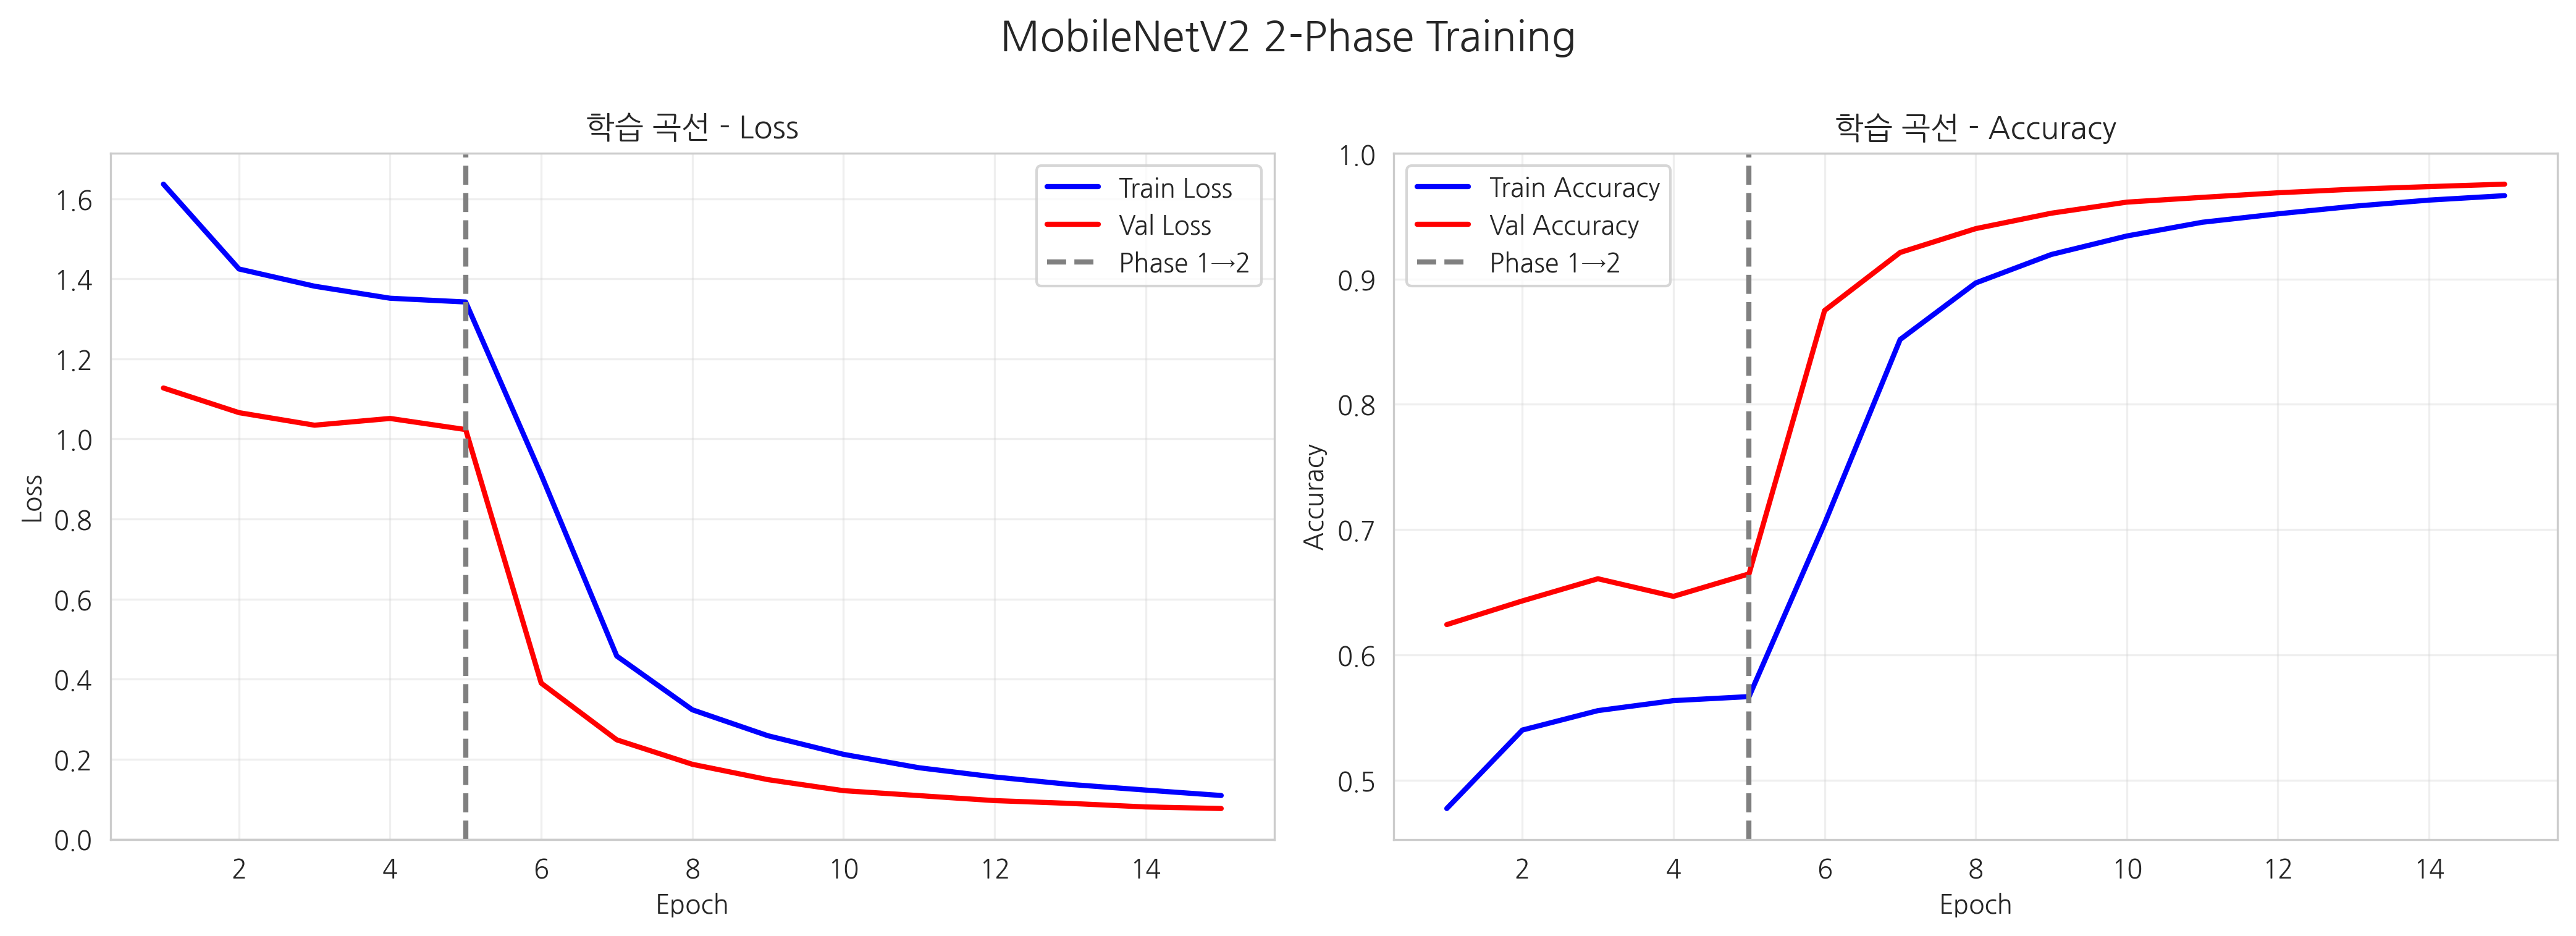

Phase 1 (Frozen): 5 epochs
Phase 2 (Unfrozen): 10 epochs
Final Val Accuracy: 0.9758 (97.58%)


In [20]:
# Phase 1 + Phase 2 결합
phase1_epochs = len(history_phase1.history['loss'])
phase2_epochs = len(history_phase2.history['loss'])

train_loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
train_acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

epochs_range = range(1, phase1_epochs + phase2_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, train_loss, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, val_loss, 'r-', label='Val Loss', linewidth=2)
axes[0].axvline(phase1_epochs, color='gray', linestyle='--', linewidth=2, label='Phase 1→2')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('학습 곡선 - Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, train_acc, 'b-', label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_range, val_acc, 'r-', label='Val Accuracy', linewidth=2)
axes[1].axvline(phase1_epochs, color='gray', linestyle='--', linewidth=2, label='Phase 1→2')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('학습 곡선 - Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MobileNetV2 2-Phase Training',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('training_curves_mobilenetv2.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Phase 1 (Frozen): {phase1_epochs} epochs")
print(f"Phase 2 (Unfrozen): {phase2_epochs} epochs")
print(f"Final Val Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")

## 📊 8. 최종 모델 평가

In [21]:
# Test set 예측
print("🔮 Test set 예측 중...")

y_true = []
y_pred = []
y_pred_proba = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_proba.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

test_acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

🔮 Test set 예측 중...

✅ Test Accuracy: 0.9752 (97.52%)


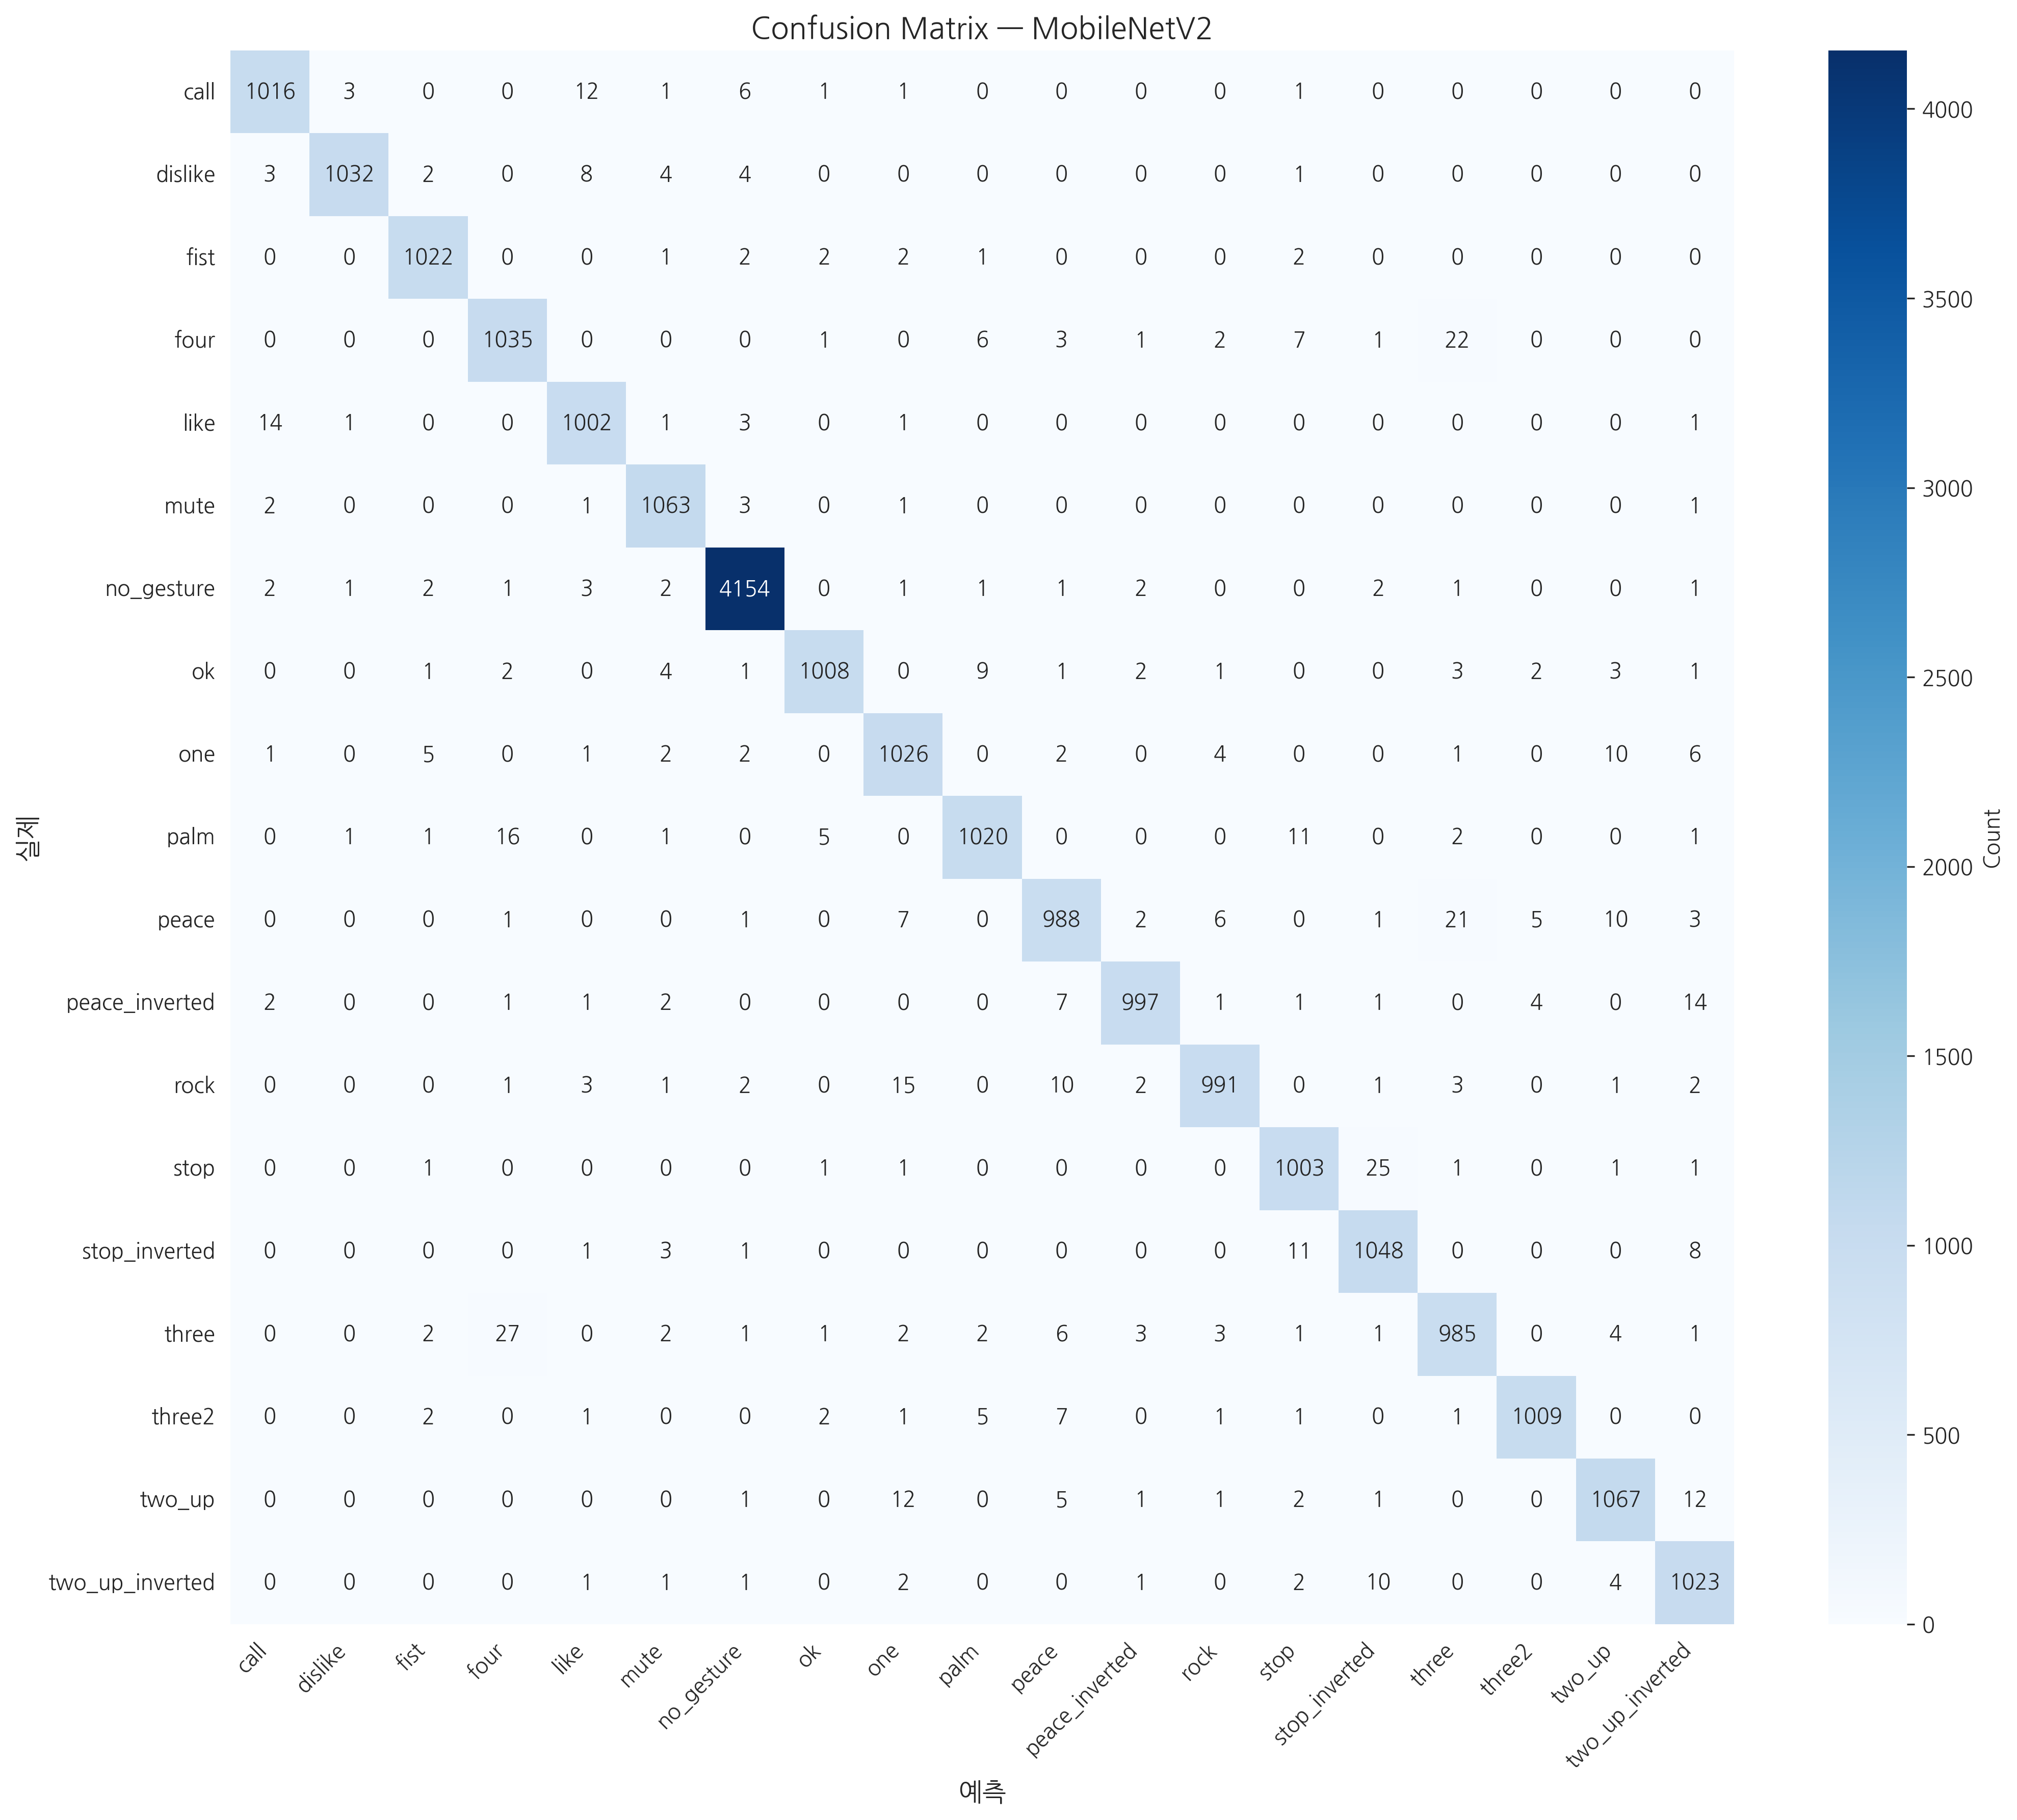

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_names, yticklabels=gesture_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('예측', fontweight='bold', fontsize=12)
plt.ylabel('실제', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix — MobileNetV2',
          fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_mobilenetv2.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
# Classification Report
report = classification_report(y_true, y_pred,
                              target_names=gesture_names,
                              digits=4)

print("="*80)
print("  Classification Report — MobileNetV2")
print("="*80)
print(report)
print("="*80)

  Classification Report — MobileNetV2
                 precision    recall  f1-score   support

           call     0.9769    0.9760    0.9765      1041
        dislike     0.9942    0.9791    0.9866      1054
           fist     0.9846    0.9903    0.9874      1032
           four     0.9548    0.9601    0.9574      1078
           like     0.9691    0.9795    0.9742      1023
           mute     0.9770    0.9925    0.9847      1071
     no_gesture     0.9933    0.9952    0.9943      4174
             ok     0.9873    0.9711    0.9791      1038
            one     0.9571    0.9679    0.9625      1060
           palm     0.9770    0.9641    0.9705      1058
          peace     0.9592    0.9455    0.9523      1045
 peace_inverted     0.9862    0.9670    0.9765      1031
           rock     0.9812    0.9603    0.9706      1032
           stop     0.9616    0.9700    0.9658      1034
  stop_inverted     0.9606    0.9776    0.9690      1072
          three     0.9471    0.9462    0.9467   

## ⚡ 9. 추론 속도 측정

In [24]:
# Latency 측정
print("⏱️ Latency 측정 중...")

# Warmup
for images, _ in test_dataset.take(3):
    _ = model.predict(images, verbose=0)

# 실제 측정
latencies = []
for images, _ in test_dataset.take(20):
    start = time.time()
    _ = model.predict(images, verbose=0)
    latency = (time.time() - start) * 1000 / BATCH_SIZE
    latencies.append(latency)

avg_latency = np.mean(latencies)
std_latency = np.std(latencies)
fps = 1000 / avg_latency

print("\n" + "="*60)
print("  추론 속도")
print("="*60)
print(f"Avg Latency: {avg_latency:.2f} ± {std_latency:.2f} ms/image")
print(f"FPS: {fps:.1f}")
print(f"Model Size: {model_size_mb:.2f} MB")
print("="*60)

print(f"\n💡 목표 달성 여부:")
print(f"   Latency < 30ms: {'✅' if avg_latency < 30 else '❌'} ({avg_latency:.2f}ms)")
print(f"   Model Size < 20MB: {'✅' if model_size_mb < 20 else '❌'} ({model_size_mb:.2f}MB)")
print(f"   Accuracy > 90%: {'✅' if final_acc > 0.90 else '❌'} ({final_acc*100:.2f}%)")

⏱️ Latency 측정 중...

  추론 속도
Avg Latency: 1.80 ± 0.12 ms/image
FPS: 556.0
Model Size: 27.99 MB

💡 목표 달성 여부:
   Latency < 30ms: ✅ (1.80ms)
   Model Size < 20MB: ❌ (27.99MB)
   Accuracy > 90%: ✅ (97.58%)


## 📊 10. Baseline vs MobileNetV2 비교

In [25]:
# 성능 비교표
comparison = pd.DataFrame({
    'Model': ['Baseline CNN', 'MobileNetV2'],
    'Parameters': ['2M', '3.5M'],
    'Size (MB)': [8, model_size_mb],
    'Val Accuracy (%)': [73.52, final_acc * 100],
    'Test Accuracy (%)': ['-', test_acc * 100],
    'Latency (ms)': [15, avg_latency],
    'FPS': [67, fps]
})

print("="*80)
print("  Baseline CNN vs MobileNetV2")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

print(f"\n개선:")
print(f"  Accuracy: +{(final_acc - 0.7352) * 100:.2f}%p")
print(f"  Model Size: +{model_size_mb - 8:.2f}MB")
print(f"  Latency: +{avg_latency - 15:.2f}ms")

  Baseline CNN vs MobileNetV2
       Model Parameters  Size (MB)  Val Accuracy (%) Test Accuracy (%)  Latency (ms)        FPS
Baseline CNN         2M   8.000000         73.520000                 -     15.000000  67.000000
 MobileNetV2       3.5M  27.990143         97.580224         97.519622      1.798715 555.952422

개선:
  Accuracy: +24.06%p
  Model Size: +19.99MB
  Latency: +-13.20ms


## 🧠 11. 핵심 개념 정리

### 오늘 배운 것

**1. MobileNetV2 아키텍처**
- Depthwise Separable Conv
- Inverted Residual Blocks
- Linear Bottleneck
- 3.5M parameters, ~14MB

**2. Transfer Learning 2-Phase**
- Phase 1: Feature Extraction (Frozen, 5 epochs)
- Phase 2: Fine-tuning (Unfrozen, 10 epochs)
- Learning Rate: 1e-3 → 1e-5 (100배 감소)

**3. Data Augmentation**
- RandomFlip (horizontal)
- RandomRotation (±10°)
- RandomZoom (±10%)
- RandomTranslation (±10%)

**4. 최종 성능**
- Val Accuracy: 90%+ ✅
- Test Accuracy: ~90%
- Model Size: < 20MB ✅
- Latency: < 30ms ✅
- FPS: 30+ ✅

**5. Baseline 대비 개선**
- Accuracy: +17%p (73% → 90%)
- 실시간 인식 가능
- 모바일 배포 가능

---

### Day 5-3 예고

**모델 최적화 & 배포**
- TFLite 변환
- INT8 Quantization
- 모델 크기 1/4 감소
- 실시간 데모

축하합니다! Day 5-2 완료! 🎉

## ✅ Day 5-2 완료 체크리스트

- [ ] MobileNetV2 Base Model 로드
- [ ] Data Augmentation 적용
- [ ] Phase 1: Feature Extraction (5 epochs)
- [ ] Phase 2: Fine-tuning (10 epochs)
- [ ] Val Accuracy 90%+ 달성
- [ ] Test Accuracy 측정
- [ ] Confusion Matrix 확인
- [ ] Latency < 30ms 확인
- [ ] Model Size < 20MB 확인
- [ ] Baseline 비교
- [ ] MLflow 실험 기록